In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from xgboost import XGBClassifier
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')


In [35]:
kz = pd.read_csv('kase.csv')
us = pd.read_csv('us.csv')
kz['date'] = pd.to_datetime(kz['date'])
us['date'] = pd.to_datetime(us['date'])
kz = kz.sort_values(['ticker','date']).reset_index(drop=True)
us = us.sort_values(['ticker','date']).reset_index(drop=True)
print(f'KZ: {kz.shape[0]} rows, {kz.shape[1]} cols, {kz.date.min().date()} -> {kz.date.max().date()}')
print(f'US: {us.shape[0]} rows, {us.shape[1]} cols, {us.date.min().date()} -> {us.date.max().date()}')


KZ: 27252 rows, 35 cols, 2019-03-15 -> 2026-03-20
US: 84277 rows, 50 cols, 2021-06-30 -> 2026-03-23


In [36]:
def create_target(df, t=0.05):
    def label(x):
        if pd.isna(x): return np.nan
        if x >  t: return 'buy'
        if x < -t: return 'sell'
        return 'hold'
    df['target'] = df['ret_fwd_20'].apply(label)
    return df

kz = create_target(kz); us = create_target(us)
print('KZ class dist:'); print(kz['target'].value_counts(dropna=False))
print('US class dist:'); print(us['target'].value_counts(dropna=False))


KZ class dist:
target
hold    17305
buy      5610
sell     4337
Name: count, dtype: int64
US class dist:
target
hold    40346
buy     24923
sell    19008
Name: count, dtype: int64


In [37]:
# Технические признаки
tech_features = ['open', 'high', 'low', 'close', 'adj_close', 'volume',
                 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'sma_20', 'sma_50',
                 'ema_12', 'ema_26', 'price_to_sma50', 'rsi_14', 'macd', 
                 'macd_signal', 'macd_hist', 'stoch_k', 'bb_upper', 'bb_lower',
                 'bb_width', 'atr_14', 'volume_ratio_20', 'volume_roc', 'obv',
                 'overnight_gap', 'intraday_range', 'sigma_20d']

# Фундаментальные признаки (только US)
fund_features = ['eps', 'revenue', 'revenue_growth_yoy', 'gross_margin', 
                 'operating_margin', 'net_margin', 'roe', 'debt_to_equity',
                 'current_ratio', 'fcf', 'operating_cf', 'pe_ttm', 'pb', 
                 'ps_ttm', 'days_since_report']

# Создаем датасеты
kz_tech = kz[tech_features + ['target']].copy()
us_tech = us[tech_features + ['target']].copy()
us_fund = us[fund_features + ['target']].copy()

print(f"KZ (технические): {kz_tech.shape[0]} строк, {kz_tech.shape[1]} колонок")
print(f"US (технические): {us_tech.shape[0]} строк, {us_tech.shape[1]} колонок")
print(f"US (фундаментальные): {us_fund.shape[0]} строк, {us_fund.shape[1]} колонок")

KZ (технические): 27252 строк, 31 колонок
US (технические): 84277 строк, 31 колонок
US (фундаментальные): 84277 строк, 16 колонок


In [38]:
def prepare_train_test(train_df, test_df, features):
    train_df = train_df.dropna(subset=["target"]).reset_index(drop=True)
    test_df  = test_df.dropna(subset=["target"]).reset_index(drop=True)
    le = LabelEncoder().fit(["buy","hold","sell"])
    y_tr = le.transform(train_df["target"]); y_te = le.transform(test_df["target"])
    Xtr = train_df[features].copy(); Xte = test_df[features].copy()
    imp = SimpleImputer(strategy="median", keep_empty_features=True).fit(Xtr)
    Xtr = pd.DataFrame(imp.transform(Xtr), columns=features)
    Xte = pd.DataFrame(imp.transform(Xte), columns=features)
    sc  = StandardScaler().fit(Xtr)
    Xtr = pd.DataFrame(sc.transform(Xtr), columns=features)
    Xte = pd.DataFrame(sc.transform(Xte), columns=features)
    return Xtr, Xte, y_tr, y_te, le, sc, imp


In [39]:
# TEMPORAL split: train <= 2024-12-31, test >= 2025-01-01 (no shuffle, no leakage)
split_date = pd.Timestamp('2025-01-01')

kz_train = kz[kz['date'] <  split_date]
kz_test  = kz[kz['date'] >= split_date]
us_train = us[us['date'] <  split_date]
us_test  = us[us['date'] >= split_date]

Xk_train, Xk_test, yk_train, yk_test, le_kz, scaler_kz, imp_kz = prepare_train_test(kz_train, kz_test, tech_features)
Xu_tech_train, Xu_tech_test, yu_tech_train, yu_tech_test, le_us_tech, scaler_us_tech, _ = prepare_train_test(us_train, us_test, tech_features)
Xu_fund_train, Xu_fund_test, yu_fund_train, yu_fund_test, le_us_fund, scaler_us_fund, _ = prepare_train_test(us_train, us_test, fund_features)

print(f'KZ:      train={len(Xk_train)}, test={len(Xk_test)}')
print(f'US tech: train={len(Xu_tech_train)}, test={len(Xu_tech_test)}')
print(f'US fund: train={len(Xu_fund_train)}, test={len(Xu_fund_test)}')


KZ:      train=20717, test=6535
US tech: train=62622, test=21655
US fund: train=62622, test=21655


In [40]:
def make_model():
    return XGBClassifier(
        objective='multi:softprob', num_class=3,
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, eval_metric='mlogloss', tree_method='hist'
    )

def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    present = sorted(set(y_test) | set(y_pred))
    names_all = ['buy','hold','sell']
    print(classification_report(y_test, y_pred, labels=present,
                                target_names=[names_all[i] for i in present], zero_division=0))
    try:
        y_test_bin = label_binarize(y_test, classes=[0,1,2])
        auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
        print(f'Weighted ROC-AUC: {auc:.4f}')
    except Exception as e:
        print(f'ROC-AUC skipped: {e}')
    return model, acc

model_kz, acc_kz = train_and_evaluate(make_model(), Xk_train, yk_train, Xk_test, yk_test, 'KZ stocks (technical)')
model_us_tech, acc_us_tech = train_and_evaluate(make_model(), Xu_tech_train, yu_tech_train, Xu_tech_test, yu_tech_test, 'US stocks (technical)')
model_us_fund, acc_us_fund = train_and_evaluate(make_model(), Xu_fund_train, yu_fund_train, Xu_fund_test, yu_fund_test, 'US stocks (fundamental)')



=== KZ stocks (technical) ===
Accuracy: 0.5752
              precision    recall  f1-score   support

         buy       0.27      0.13      0.17      1391
        hold       0.63      0.88      0.73      3925
        sell       0.33      0.10      0.16      1219

    accuracy                           0.58      6535
   macro avg       0.41      0.37      0.35      6535
weighted avg       0.50      0.58      0.51      6535

Weighted ROC-AUC: 0.6575

=== US stocks (technical) ===
Accuracy: 0.4165
              precision    recall  f1-score   support

         buy       0.33      0.24      0.27      6715
        hold       0.46      0.71      0.56      9849
        sell       0.26      0.08      0.13      5091

    accuracy                           0.42     21655
   macro avg       0.35      0.34      0.32     21655
weighted avg       0.37      0.42      0.37     21655

Weighted ROC-AUC: 0.5322

=== US stocks (fundamental) ===
Accuracy: 0.3438
              precision    recall  f1-scor

In [41]:
dummy = DummyClassifier(strategy='most_frequent').fit(Xk_train, yk_train)
dummy_pred = dummy.predict(Xk_test)
dummy_acc = accuracy_score(yk_test, dummy_pred)
print(f'Baseline (most_frequent) on KZ test: {dummy_acc:.4f}')
print(f'XGB improvement over baseline: {acc_kz - dummy_acc:+.4f}')


Baseline (most_frequent) on KZ test: 0.6006
XGB improvement over baseline: -0.0254



              Модель  Accuracy  Признаков F1-score (macro)
    KZ (технические)  0.575210         30           0.3547
    US (технические)  0.416532         30           0.3207
US (фундаментальные)  0.343801         15           0.2972
            Бейзлайн  0.600612          0           0.2502


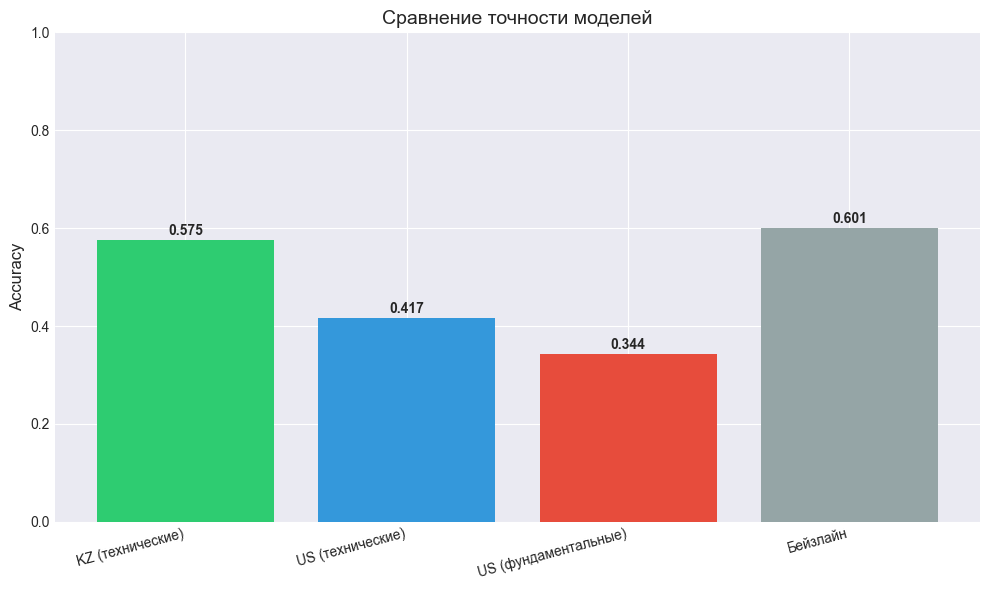

In [42]:
comparison_data = {
    'Модель': ['KZ (технические)', 'US (технические)', 'US (фундаментальные)', 'Бейзлайн'],
    'Accuracy': [acc_kz, acc_us_tech, acc_us_fund, dummy_acc],
    'Признаков': [len(tech_features), len(tech_features), len(fund_features), 0],
    'F1-score (macro)': [
        f1_score(yk_test, model_kz.predict(Xk_test), average='macro'),
        f1_score(yu_tech_test, model_us_tech.predict(Xu_tech_test), average='macro'),
        f1_score(yu_fund_test, model_us_fund.predict(Xu_fund_test), average='macro'),
        f1_score(yk_test, dummy_pred, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['F1-score (macro)'] = comparison_df['F1-score (macro)'].apply(lambda x: f"{x:.4f}")
print("\n" + comparison_df.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
bars = ax.bar(comparison_df['Модель'], [acc_kz, acc_us_tech, acc_us_fund, dummy_acc], color=colors)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Сравнение точности моделей', fontsize=14)
ax.set_ylim(0, 1)
for bar, acc in zip(bars, [acc_kz, acc_us_tech, acc_us_fund, dummy_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [43]:
def walk_forward_cv(X, y, name, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = cross_val_score(make_model(), X, y, cv=tscv, scoring='accuracy', n_jobs=1)
    print(f'{name}: mean acc={scores.mean():.4f} (+/- {scores.std():.4f}) | folds={[f"{s:.4f}" for s in scores]}')
    return scores

# Walk-forward CV on training window only (no test leakage)
_ = walk_forward_cv(Xk_train, yk_train, 'KZ (technical)')
_ = walk_forward_cv(Xu_tech_train, yu_tech_train, 'US (technical)')


KZ (technical): mean acc=0.5523 (+/- 0.0904) | folds=['0.6840', '0.4186', '0.5183', '0.5264', '0.6141']
US (technical): mean acc=0.4478 (+/- 0.0421) | folds=['0.3719', '0.4733', '0.4827', '0.4320', '0.4793']



Топ-10 самых важных признаков (корреляция с таргетом):
   rsi_14: 0.1013
   obv: 0.0746
   stoch_k: 0.0515
   volume_ratio_20: 0.0171
   volume: 0.0157
   ret_20d: 0.0012
   price_to_sma50: -0.0010
   volume_roc: -0.0070
   macd_signal: -0.0094


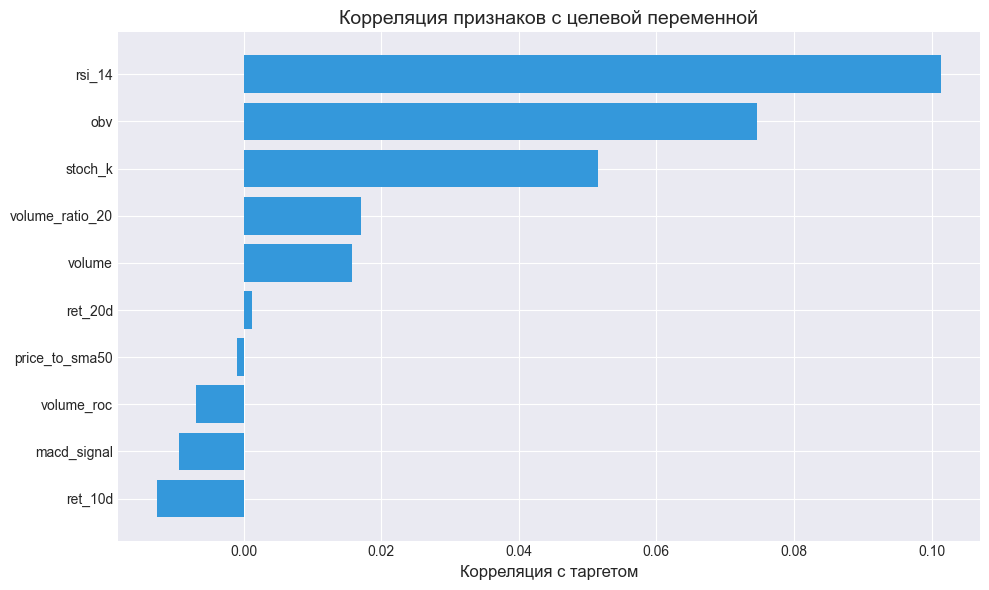

In [44]:
# Кодируем target для корреляции
kz_corr = kz[tech_features].copy()
kz_corr['target_num'] = kz['target'].map({'buy': 2, 'hold': 1, 'sell': 0})

correlations = kz_corr.corr()['target_num'].sort_values(ascending=False)

print("\nТоп-10 самых важных признаков (корреляция с таргетом):")
for feat, corr in correlations.head(10).items():
    if feat != 'target_num':
        print(f"   {feat}: {corr:.4f}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
top_features = correlations.head(11).drop('target_num', errors='ignore')
bars = ax.barh(range(len(top_features)), top_features.values, color='#3498db')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Корреляция с таргетом', fontsize=12)
ax.set_title('Корреляция признаков с целевой переменной', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Топ-10 важных признаков для KZ акции:
   bb_width: 0.0684
   sigma_20d: 0.0469
   ema_26: 0.0461
   ema_12: 0.0439
   atr_14: 0.0434
   bb_upper: 0.0434
   sma_50: 0.0433
   obv: 0.0419
   bb_lower: 0.0413
   low: 0.0408


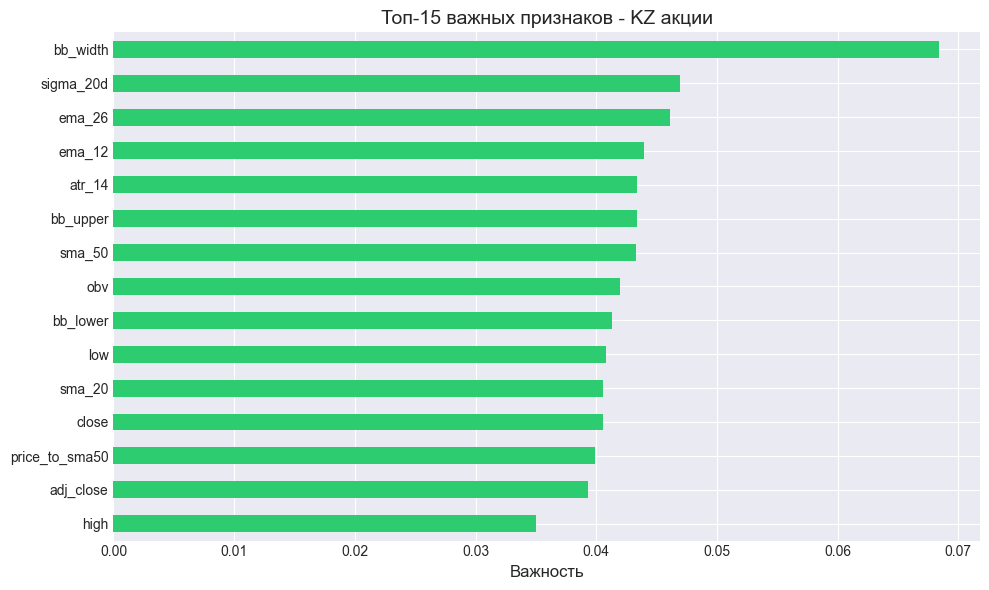


Топ-10 важных признаков для US акции (технические):
   sigma_20d: 0.0501
   ema_12: 0.0443
   ema_26: 0.0442
   sma_50: 0.0439
   bb_lower: 0.0422
   atr_14: 0.0422
   adj_close: 0.0404
   bb_upper: 0.0404
   sma_20: 0.0398
   close: 0.0396


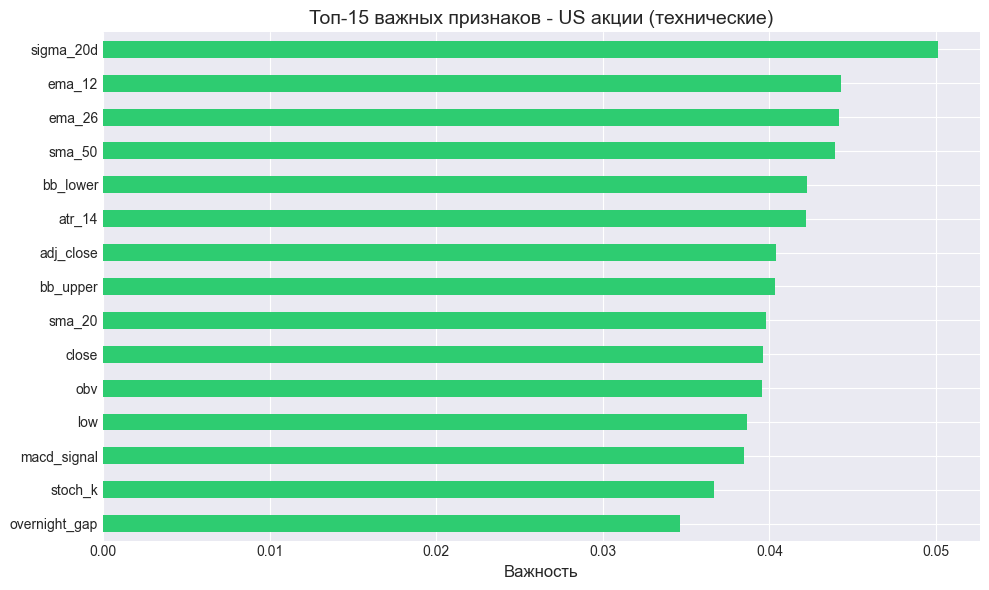

In [45]:
def plot_feature_importance(model, feature_names, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False).head(15)
    
    print(f"\nТоп-10 важных признаков для {title}:")
    for feat, imp in importance.head(10).items():
        print(f"   {feat}: {imp:.4f}")
    
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh', color='#2ecc71')
    plt.xlabel('Важность', fontsize=12)
    plt.title(f'Топ-15 важных признаков - {title}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_feature_importance(model_kz, Xk_train.columns, "KZ акции")
plot_feature_importance(model_us_tech, Xu_tech_train.columns, "US акции (технические)")


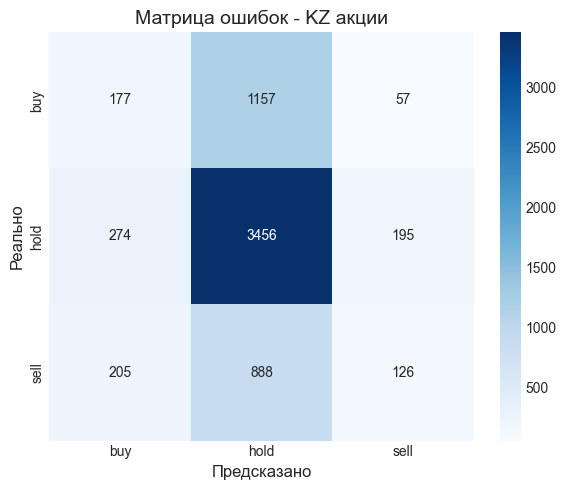


Анализ ошибок для KZ акции:
   Правильно предсказано: 3759/6535 (57.5%)
   Ошибок всего: 2776 (42.5%)


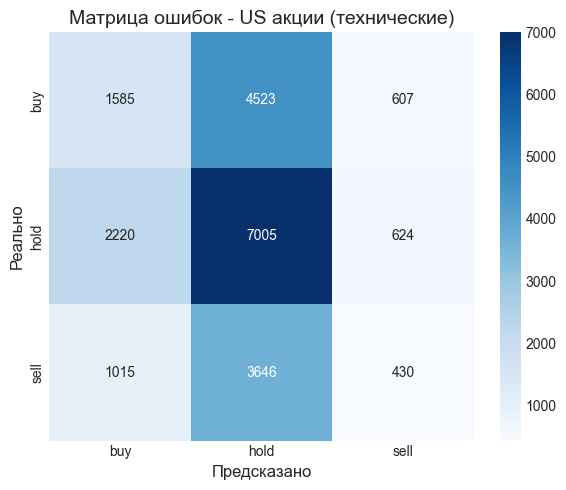


Анализ ошибок для US акции (технические):
   Правильно предсказано: 9020/21655 (41.7%)
   Ошибок всего: 12635 (58.3%)


In [46]:
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['buy', 'hold', 'sell'],
                yticklabels=['buy', 'hold', 'sell'])
    plt.xlabel('Предсказано', fontsize=12)
    plt.ylabel('Реально', fontsize=12)
    plt.title(f'Матрица ошибок - {title}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Анализ ошибок
    print(f"\nАнализ ошибок для {title}:")
    print(f"   Правильно предсказано: {cm.trace()}/{cm.sum()} ({cm.trace()/cm.sum()*100:.1f}%)")
    
    # Ошибки между классами
    misclassified = cm.sum() - cm.trace()
    print(f"   Ошибок всего: {misclassified} ({misclassified/cm.sum()*100:.1f}%)")

plot_confusion_matrix(model_kz, Xk_test, yk_test, "KZ акции")
plot_confusion_matrix(model_us_tech, Xu_tech_test, yu_tech_test, "US акции (технические)")

In [47]:
best_model = max([("KZ (технические)", acc_kz), 
                  ("US (технические)", acc_us_tech),
                  ("US (фундаментальные)", acc_us_fund)], key=lambda x: x[1])

print(f"""
ЛУЧШАЯ МОДЕЛЬ: {best_model[0]} с accuracy = {best_model[1]:.4f} ({best_model[1]*100:.1f}%)

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Казахстанский рынок предсказывается ЛУЧШЕ ({acc_kz*100:.1f}% vs {acc_us_tech*100:.1f}%)
    Возможно, рынок менее эффективен  больше аномалий для захвата

2. Технические признаки важнее фундаментальных
    Для краткосрочного прогнозирования (20 дней) технический анализ работает лучше

3. Бейзлайн показал {dummy_acc*100:.1f}%
    Наша модель лучше бейзлайна на {(acc_kz - dummy_acc)*100:.1f}%

""")


ЛУЧШАЯ МОДЕЛЬ: KZ (технические) с accuracy = 0.5752 (57.5%)

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Казахстанский рынок предсказывается ЛУЧШЕ (57.5% vs 41.7%)
    Возможно, рынок менее эффективен  больше аномалий для захвата

2. Технические признаки важнее фундаментальных
    Для краткосрочного прогнозирования (20 дней) технический анализ работает лучше

3. Бейзлайн показал 60.1%
    Наша модель лучше бейзлайна на -2.5%




In [48]:
joblib.dump(model_kz, 'model_kz.pkl')
joblib.dump(le_kz, 'label_encoder_kz.pkl')
joblib.dump(scaler_kz, 'scaler_kz.pkl')
joblib.dump(tech_features, 'features_list.pkl')

print("Модель сохранена как 'model_kz.pkl'")
print("Label encoder сохранён как 'label_encoder_kz.pkl'")
print("Scaler сохранён как 'scaler_kz.pkl'")
print("Список признаков сохранён как 'features_list.pkl'")

Модель сохранена как 'model_kz.pkl'
Label encoder сохранён как 'label_encoder_kz.pkl'
Scaler сохранён как 'scaler_kz.pkl'
Список признаков сохранён как 'features_list.pkl'
